## Part 1 - Toy Dataset

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

### Q1.a

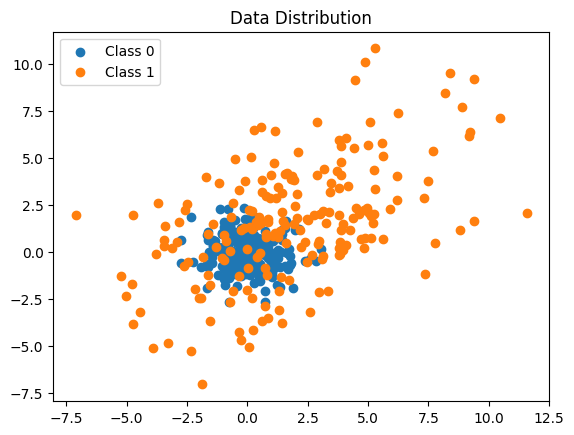

In [3]:
# Class 0: N([0, 0], I2)
mean0 = torch.tensor([0.0, 0.0])
cov0  = torch.eye(2)

# Class 1: N([2, 2], [[10, 5], [5, 10]])
mean1 = torch.tensor([2.0, 2.0])
cov1  = torch.tensor([[10.0, 5.0],
                      [ 5.0,10.0]])

dist0 = torch.distributions.MultivariateNormal(mean0, covariance_matrix=cov0)
dist1 = torch.distributions.MultivariateNormal(mean1, covariance_matrix=cov1)

n_per_class = 200
X0 = dist0.sample((n_per_class,))          # (200, 2)
X1 = dist1.sample((n_per_class,))          # (200, 2)

plt.scatter(X0[:, 0], X0[:, 1], label='Class 0')
plt.scatter(X1[:, 0], X1[:, 1], label='Class 1')
plt.legend()
plt.title('Data Distribution')
plt.show()

### Q1.b et Q1.c

In [4]:
X = torch.cat([X0, X1], dim=0).to(torch.float32)
y = torch.cat([
    torch.zeros(n_per_class, dtype=torch.long),
    torch.ones(n_per_class,  dtype=torch.long)
])

perm = torch.randperm(len(X))
X, y = X[perm], y[perm]

Training accuracy (QDA): 85.50%
(40000,)
(200, 200)


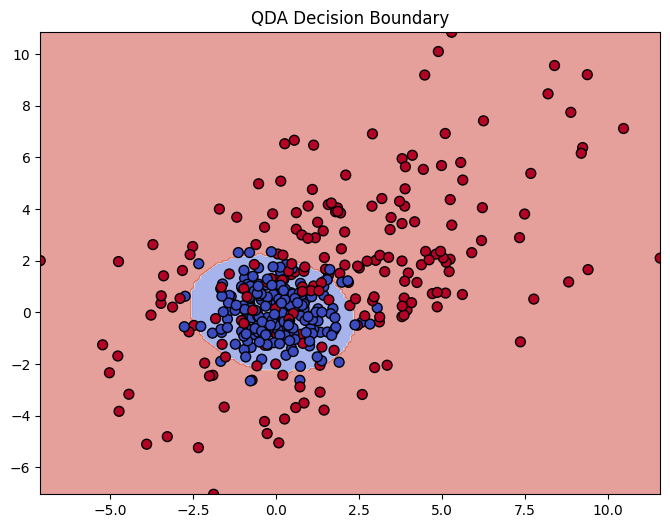

In [5]:
# Quadratic Discriminant Analysis model

clf = QuadraticDiscriminantAnalysis()
clf.fit(X, y)
print(f"Training accuracy (QDA): {clf.score(X, y)*100:.2f}%")

# plot decision boundary
plt.figure(figsize=(8, 6))
xx, yy = np.meshgrid(np.linspace(X[:, 0].min(), X[:, 0].max(), 200), np.linspace(X[:, 1].min(), X[:, 1].max(), 200))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]) # this gives a flat array of predictions for each point in the grid
print(Z.shape)
Z = Z.reshape(xx.shape) 
print(Z.shape)
plt.contourf(xx, yy, Z, alpha=0.5, cmap='coolwarm')
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', s=50, cmap='coolwarm')
plt.title('QDA Decision Boundary')
plt.show()

### Analyse Discriminante Linéaire (LDA)

Fonction de régression:
$$
\eta_\theta(x)=\mathbb{Q}_\theta(Y=1\mid X=x)
= \frac{\pi_1\,e^{-\frac12(x-\mu_1)^\top\Sigma^{-1}(x-\mu_1)}}
{\pi_1\,e^{-\frac12(x-\mu_1)^\top\Sigma^{-1}(x-\mu_1)}
+ \pi_0\,e^{-\frac12(x-\mu_0)^\top\Sigma^{-1}(x-\mu_0)}}
= sigm(\phi_\theta(x))
$$

On en déduit que
$$
\phi_\theta(x)=(\mu_1-\mu_0)^\top \Sigma^{-1}x-\frac12\,\mu_1^\top\Sigma^{-1}\mu_1+\frac12\,\mu_0^\top\Sigma^{-1}\mu_0+\ln\!\Big(\frac{\pi_1}{\pi_0}\Big)=w_\theta^\top x + A_\theta
$$

La règle de décision bayésienne est
$$
g_\theta^\star(x)=\mathbf{1}\{\eta_\theta(x)\ge 1/2\}
=\mathbf{1}\{w_\theta^\top x + A_\theta \ge 0\}.
$$

La frontière de décision est un hyperplan normal à $w_\theta$ : d’un côté “classe $0$”, de l’autre “classe $1$”. C’est la LDA.

EMV consistants (ces résultats ont été obtenus dans l'exercice 3 de la PC8):

$$
\widehat{\pi}_{0,n}=\frac1n\sum_{k=1}^n \mathbf{1}\{Y_k=0\},\quad
\widehat{\mu}_{0,n}=\frac{\sum_{k=1}^n \mathbf{1}\{Y_k=0\}X_k}{\sum_{k=1}^n \mathbf{1}\{Y_k=0\}},\quad
\widehat{\mu}_{1,n}=\frac{\sum_{k=1}^n \mathbf{1}\{Y_k=1\}X_k}{\sum_{k=1}^n \mathbf{1}\{Y_k=1\}}.
$$
$$
\widehat{\Sigma}_n
=\frac1n\sum_{k=1}^n\Big[
\mathbf{1}\{Y_k=0\}(X_k-\widehat\mu_{0,n})(X_k-\widehat\mu_{0,n})^\top
+\mathbf{1}\{Y_k=1\}(X_k-\widehat\mu_{1,n})(X_k-\widehat\mu_{1,n})^\top
\Big]
$$

En remplaçant $\theta=(\pi_0,\pi_1,\mu_0,\mu_1,\Sigma)$ par ses EMV, on définit
$
\widehat \eta_n(x)=\mathrm{sigm}\big(\widehat \phi_n(x)\big),\qquad
\widehat \phi_n(x)=\widehat w_n^\top x + \widehat A_n,
$
avec
$
\widehat w_n=\widehat\Sigma_n^{-1}\big(\widehat\mu_{1,n}-\widehat\mu_{0,n}\big),\qquad
\widehat A_n=-\tfrac12\,\widehat\mu_{1,n}^\top\widehat\Sigma_n^{-1}\widehat\mu_{1,n}
+\tfrac12\,\widehat\mu_{0,n}^\top\widehat\Sigma_n^{-1}\widehat\mu_{0,n}
+\ln\!\Big(\tfrac{\widehat\pi_{1,n}}{\widehat\pi_{0,n}}\Big).
$

**Règle de prédiction (étiquettes $0/1$) :**
$
\widehat Y_n(x)=\mathbf{1}\{\widehat \eta_n(x)\ge\tfrac12\}
=\mathbf{1}\{\widehat w_n^\top x+\widehat A_n\ge 0\}.
$


In [6]:
# Linear Discriminant Analysis model

def fit_lda(X: torch.Tensor, y: torch.Tensor):
    X = X.to(torch.float64)
    y = y.to(torch.long)

    mask0 = (y == 0) 
    mask1 = ~mask0
    n = X.shape[0]
    n0 = mask0.sum().item() # number of class 0 samples
    n1 = mask1.sum().item()

    # Priors (EMV)
    pi0_hat = n0 / n
    pi1_hat = n1 / n

    # Class means (EMV)
    mu0_hat = X[mask0].mean(dim=0)
    mu1_hat = X[mask1].mean(dim=0)

    # Pooled covariance (EMV with 1/n)
    X0_c = X[mask0] - mu0_hat
    X1_c = X[mask1] - mu1_hat
    # (n x d)^T @ (n x d) -> (d x d)
    S0 = X0_c.T @ X0_c
    S1 = X1_c.T @ X1_c
    Sigma_hat = (S0 + S1) / n

    # Inverse covariance
    Sigma_inv = torch.linalg.inv(Sigma_hat)

    # w_hat and A_hat
    delta_mu = (mu1_hat - mu0_hat)                   # (d,)
    w_hat = Sigma_inv @ delta_mu                     # (d,)
    A_hat = (
        -0.5 * (mu1_hat @ (Sigma_inv @ mu1_hat))
        + 0.5 * (mu0_hat @ (Sigma_inv @ mu0_hat))
        + torch.log(torch.tensor(pi1_hat / pi0_hat, dtype=X.dtype))
    )

    return {
        "pi0": pi0_hat, "pi1": pi1_hat,
        "mu0": mu0_hat, "mu1": mu1_hat,
        "Sigma": Sigma_hat, "Sigma_inv": Sigma_inv,
        "w_hat": w_hat, "A_hat": A_hat
    }

def lda_phi(X: torch.Tensor, params: dict) -> torch.Tensor:
    """ phi_hat(x) = w^T x + A, vectorized over rows of X. """
    X = X.to(torch.float64)
    return X @ params["w_hat"] + params["A_hat"]

def lda_predict(X: torch.Tensor, params: dict) -> torch.Tensor:
    """ Class prediction 0/1 using sign of phi (or eta >= 1/2). """
    phi = lda_phi(X, params)
    return (phi >= 0).to(torch.long)

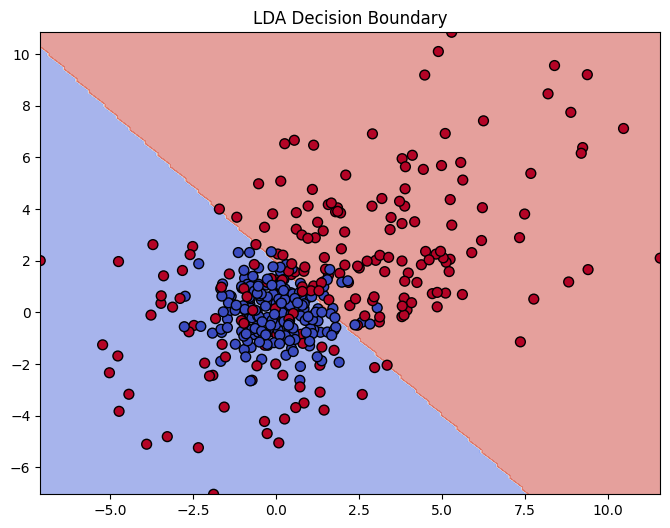

In [7]:
params = fit_lda(X, y)

# plot decision boundary
plt.figure(figsize=(8, 6))
xx, yy = np.meshgrid(np.linspace(X[:, 0].min(), X[:, 0].max(), 200), np.linspace(X[:, 1].min(), X[:, 1].max(), 200))
# predict on grid points
points = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float64)
Z = lda_predict(points, params)
Z = Z.reshape(xx.shape) 
plt.contourf(xx, yy, Z, alpha=0.5, cmap='coolwarm')
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', s=50, cmap='coolwarm')
plt.title('LDA Decision Boundary')
plt.show()

### Q1.d

La QDA s’adapte mieux à ce jeu de données que la LDA. En effet, les deux classes ne sont pas séparables par une droite : les points de la classe 0 sont encerclés par ceux de la classe 1, ce qui rend la frontière quadratique plus efficace. De plus, la LDA suppose une matrice de covariance identique pour les deux classes, hypothèse violée ici puisque les données ont été générées avec des covariances différentes. La QDA, qui autorise une covariance par classe, capture ainsi mieux la géométrie réelle des données.

### Q2.a

In [8]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold, cross_val_score

transform = transforms.Compose([transforms.ToTensor()])
train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_data = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

X = torch.cat([train_data.data, test_data.data]).float() / 255.0
y = torch.cat([train_data.targets, test_data.targets])
y_binary = (y % 2 != 0).long()  # 0=even, 1=odd

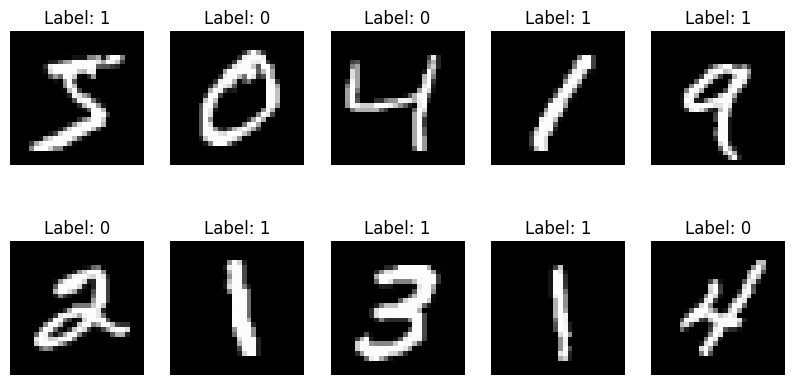

In [9]:
# plot of some images with their labels
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i in range(10):
    ax = axes[i // 5, i % 5]
    ax.imshow(X[i].squeeze(), cmap='gray')
    ax.set_title(f"Label: {y_binary[i].item()}")
    ax.axis('off')

plt.show()

### Q2.b

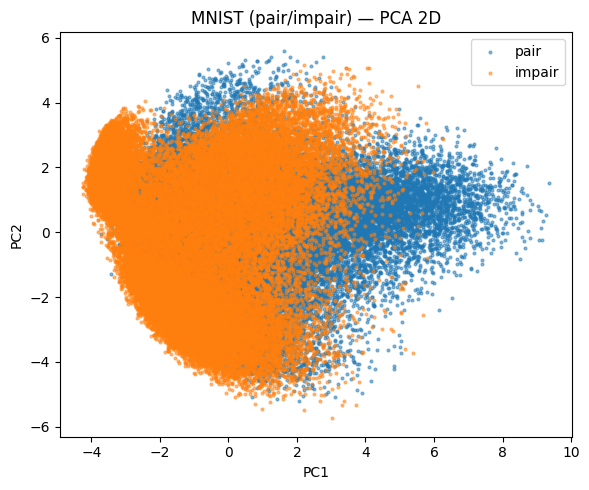

In [10]:
# Aplatir
X_flat = X.view(len(X), -1).numpy()   # (n, 784)
y_np   = y_binary.numpy()

# PCA 2D
pca2 = PCA(n_components=2)
Z2 = pca2.fit_transform(X_flat)                 # (n, 2)

# Scatter
plt.figure(figsize=(6,5))
for cls, name in [(0,"pair"), (1,"impair")]:
    m = (y_np==cls)
    plt.scatter(Z2[m,0], Z2[m,1], s=4, alpha=0.5, label=name)
plt.legend(); plt.title("MNIST (pair/impair) — PCA 2D") 
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.tight_layout(); plt.show()

La répartition des classes dans ce nouveau espace permet d'identifier que les points impairs prédominent à la gauche alors que les pairs à la droite. Cependant, vue qu'il y a beaucoup de régions où la densité de points de chaque classe est similaire (i.e. les classes ne sont pas régroupées dans des zones distinctes), on peut donc observer que la méthode ACP en dimension 2 n'est pas efficace pour la classification de ce jeu de données.

### Q2.c

Accuracy (moy±std): 0.6525 ± 0.0053
Recall   (moy±std): 0.7099 ± 0.0051


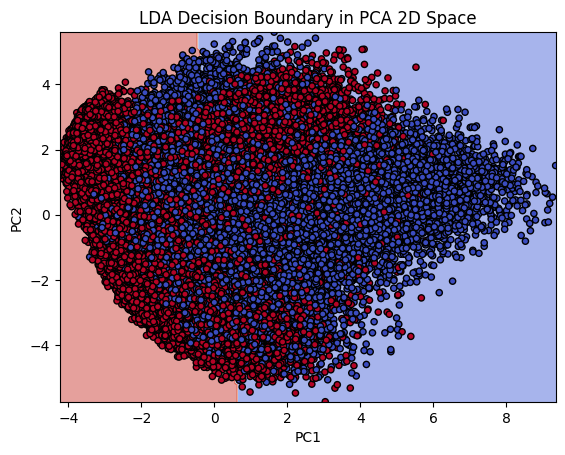

In [11]:
from sklearn.metrics import make_scorer, recall_score

lda_2d = LinearDiscriminantAnalysis()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

acc = cross_val_score(lda_2d, Z2, y_np, cv=cv, scoring="accuracy")
rec = cross_val_score(lda_2d, Z2, y_np, cv=cv,
                      scoring=make_scorer(recall_score, average="binary"))

print(f"Accuracy (moy±std): {acc.mean():.4f} ± {acc.std():.4f}")
print(f"Recall   (moy±std): {rec.mean():.4f} ± {rec.std():.4f}")

# Plot decision boundary in 2D PCA space
lda_2d.fit(Z2, y_np)
xx, yy = np.meshgrid(
    np.linspace(Z2[:,0].min(), Z2[:,0].max(), 200),
    np.linspace(Z2[:,1].min(), Z2[:,1].max(), 200)
)
Z = lda_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.5, cmap='coolwarm')
plt.scatter(Z2[:, 0], Z2[:, 1], c=y_np, edgecolor='k', s=20, cmap='coolwarm')
plt.title('LDA Decision Boundary in PCA 2D Space')
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.show()

### Q2.d

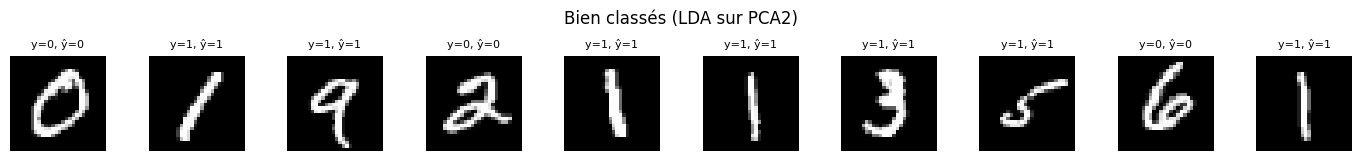

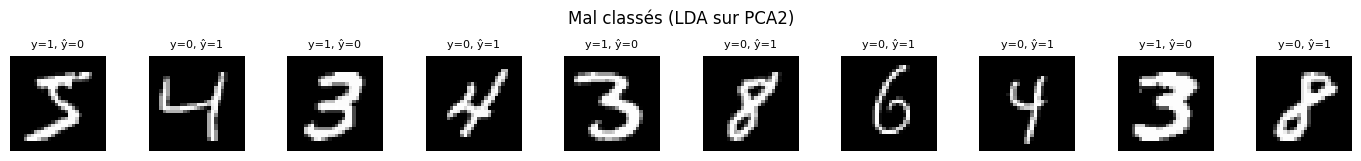

In [12]:
# Fit sur tout Z2 pour illustrer
lda_2d.fit(Z2, y_np)
y_hat = lda_2d.predict(Z2)

ok_idx  = np.where(y_hat == y_np)[0][:10]
bad_idx = np.where(y_hat != y_np)[0][:10]

def show_grid(idxs, title):
    n = len(idxs)
    cols = 10
    rows = int(np.ceil(n/cols))
    plt.figure(figsize=(1.4*cols, 1.6*rows))
    for k,i in enumerate(idxs):
        plt.subplot(rows, cols, k+1)
        plt.imshow(X[i].squeeze(), cmap="gray")
        plt.axis("off")
        plt.title(f"y={y_np[i]}, ŷ={y_hat[i]}", fontsize=8)
    plt.suptitle(title); plt.tight_layout(); plt.show()

show_grid(ok_idx,  "Bien classés (LDA sur PCA2)")
show_grid(bad_idx, "Mal classés (LDA sur PCA2)")


### Q2.e 

In [13]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(nn.Linear(32*7*7, 64), nn.ReLU(), nn.Linear(64, 1))
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        h = self.fc[0:2](x)  # penultimate activations
        out = self.fc[2](h)
        return out, h

model = SmallCNN()
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.BCEWithLogitsLoss()

dataset = TensorDataset(X.unsqueeze(1), y_binary.float())
loader = DataLoader(dataset, batch_size=128, shuffle=True)

n_epochs = 5
model.train()

for epoch in range(n_epochs):
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        out, _ = model(xb)
        train_loss = loss_fn(out.squeeze(), yb)
        opt.zero_grad()
        train_loss.backward()
        opt.step()
        
    print(f"Epoch {epoch+1}, loss={train_loss.item():.4f}")

Epoch 1, loss=0.0728
Epoch 2, loss=0.0585
Epoch 3, loss=0.0663
Epoch 4, loss=0.0120
Epoch 5, loss=0.0281


In [14]:
# Extraction des 64-dim features
model.eval()
feat_loader = DataLoader(dataset, batch_size=256, shuffle=False)  # garder l'ordre
all_feats = []
all_y = []

with torch.no_grad():
    for xb, yb in feat_loader:
        xb = xb.to(device)
        _, h = model(xb)              # h: (B, 64)
        all_feats.append(h.cpu())
        all_y.append(yb.cpu())

FEATS = torch.cat(all_feats, dim=0)   # (N, 64)  activations pénultièmes
Y_BIN = torch.cat(all_y, dim=0)       # (N,)     labels (float ici)
print(FEATS.shape, Y_BIN.shape)

torch.Size([70000, 64]) torch.Size([70000])


### Q2.f

In [15]:
lda_feat = LinearDiscriminantAnalysis()
acc_f = cross_val_score(lda_feat, FEATS, y_np, cv=cv, scoring="accuracy")
rec_f = cross_val_score(lda_feat, FEATS, y_np, cv=cv,
                        scoring=make_scorer(recall_score, average="binary"))

print(f"[CNN-feats] Accuracy (moy±std): {acc_f.mean():.4f} ± {acc_f.std():.4f}")
print(f"[CNN-feats] Recall   (moy±std): {rec_f.mean():.4f} ± {rec_f.std():.4f}")

[CNN-feats] Accuracy (moy±std): 0.9899 ± 0.0003
[CNN-feats] Recall   (moy±std): 0.9900 ± 0.0005


### Q2.g

Top-10 EVR: [0.709  0.1265 0.0626 0.0309 0.0263 0.0115 0.0103 0.005  0.0037 0.0028]
Cumul à 10: [0.709  0.8355 0.8981 0.929  0.9553 0.9668 0.977  0.9821 0.9858 0.9886]
Nombre de composantes pour ≥95% variance: k=5


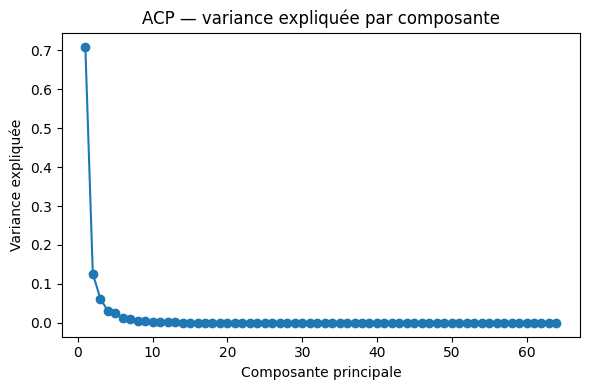

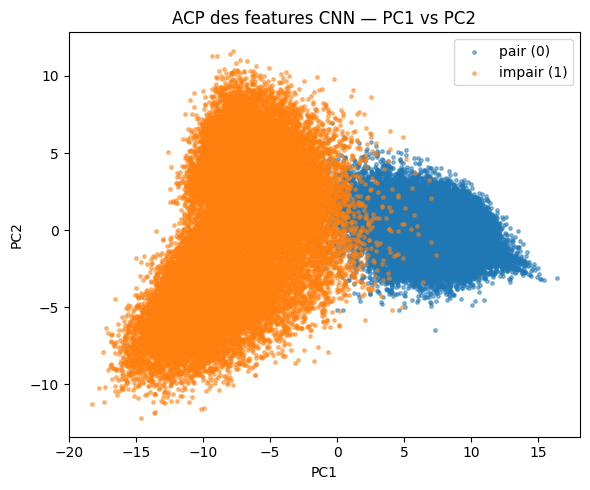

[LDA sur ACP(k=2)] Accuracy: 0.9892 ± 0.0006


In [ ]:
Xf = FEATS.cpu().numpy().astype(np.float64)
y  = Y_BIN.cpu().numpy().astype(int)

# ACP complète en dimension 64
pca = PCA(n_components=64)
Z = pca.fit_transform(Xf)   # (N, n_comp)

# Variance expliquée
evr = pca.explained_variance_ratio_
cev = np.cumsum(evr) # cumulative explained variance
print("Top-10 EVR:", np.round(evr[:10], 4))
print("Cumul à 10:", np.round(cev[:10], 4))
k95 = int(np.searchsorted(cev, 0.95) + 1)
print(f"Nombre de composantes pour ≥95% variance: k={k95}")

# Graphiques (variance expliquée + scatter PC1/PC2)
plt.figure(figsize=(6,4))
plt.plot(np.arange(1, len(evr)+1), evr, marker="o")
plt.xlabel("Composante principale")
plt.ylabel("Variance expliquée")
plt.title("ACP — variance expliquée par composante")
plt.tight_layout(); plt.show()

plt.figure(figsize=(6,5))
mask0 = (y == 0); mask1 = ~mask0
plt.scatter(Z[mask0,0], Z[mask0,1], s=6, alpha=0.5, label="pair (0)")
plt.scatter(Z[mask1,0], Z[mask1,1], s=6, alpha=0.5, label="impair (1)")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("ACP des features CNN — PC1 vs PC2")
plt.legend(); plt.tight_layout(); plt.show()

# réduire à 2 composantes pour LDA
Zk = Z[:, :2]

# LDA en CV pour voir le gain
lda = LinearDiscriminantAnalysis()
acc = cross_val_score(lda, Zk, y, cv=cv, scoring="accuracy")
print(f"[LDA sur ACP(k=2)] Accuracy: {acc.mean():.4f} ± {acc.std():.4f}")


Sur les pixels bruts, la frontière linéaire (LDA) est limitée : la séparation pair/impair n’est pas linéarisable facilement dans l’espace brut de dimension 784 (faible séparabilité sur PCA2).

Les features CNN apprennent des motifs locaux (bords, courbes, compositions), rendant les classes bien plus séparables linéairement: la LDA sur ces 64 dimensions exploite cette représentation plus informative et atteint de meilleures métriques. Une PCA sur ces features montrera une séparabilité plus claire